In [1]:
%cd ../..

f:\nn


# Importing Libraries

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
from PIL import Image

import optuna

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split
from torchvision import transforms

from tqdm import tqdm

from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

from utils.training import train_model, evaluate_model
from utils.visualization import plot_training_curves, plot_confusion_matrix
from utils.dataset import CrackDataset
from utils.config import FFNN_CONFIG, FFNN_SEARCH_SPACE
from utils.hparam_search import run_search, plot_search_results

f:\nn\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Importing our dataset

,class,resized_path
0,Non Cracked,data\cracked_vs_non_cracked_resized\Non Cracke...
1,Non Cracked,data\augmented_images\7050-6_resized_aug2.jpeg
2,Non Cracked,data\cracked_vs_non_cracked_resized\Non Cracke...
3,Non Cracked,data\cracked_vs_non_cracked_resized\Non Cracke...
4,Non Cracked,data\augmented_images\7119-100_resized_aug2.jpeg
5,Non Cracked,data\cracked_vs_non_cracked_resized\Non Cracke...
6,Non Cracked,data\augmented_images\14397_resized_aug0.jpeg
7,Non Cracked,data\augmented_images\16418_resized_aug0.jpeg
8,Non Cracked,data\augmented_images\047-50_resized_aug1.jpeg
9,Non Cracked,data\augmented_images\7103-214_resized_aug1.jpeg


Class distribution:


<Axes: xlabel='class'>

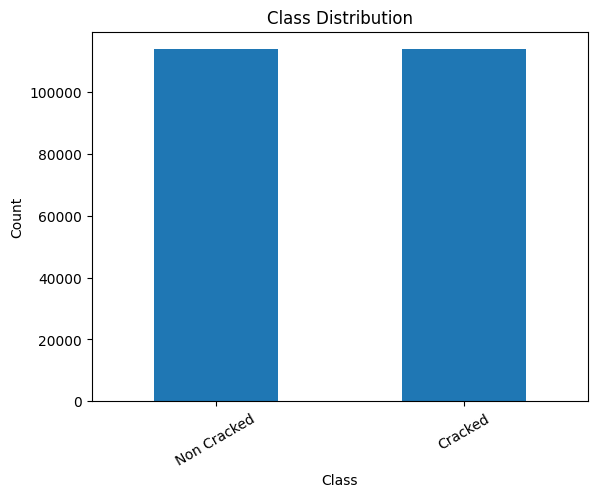

In [3]:
df = pd.read_csv('data/trainable_df.csv')
display(df.head(10))
print("="*80)
print("Class distribution:")
display(df['class'].value_counts().plot(kind='bar'))
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.show()

# Preparing our data

## Image resize

> A FFNN is made up of fully connected linear layers where every neuron connects to every input. These layers expect a flat 1D vector as input — they have no concept of spatial structure like rows and columns. An image is inherently 2D (64, 64), so it needs to be flattened into a single sequence of 4,096 pixel values before the network can process it. 

>This is also why we resize from 227x227 down to 64x64 — flattening a 227x227 image gives 51,529 input features, meaning the first linear layer alone would have tens of millions of parameters, making the model extremely slow to train and highly prone to overfitting. 

>At 64x64 we get a manageable 4,096 features while retaining enough visual information for the model to learn from. This is unlike a CNN which uses convolutional filters that slide over the 2D image and explicitly exploit spatial relationships between neighboring pixels, making it far better suited for high resolution image inputs.

In [4]:
transformations = transforms.Compose([
    transforms.Resize((FFNN_CONFIG['image_size'], FFNN_CONFIG['image_size'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
    transforms.Lambda(lambda x: x.view(-1)),  # flatten → (4096,)
])

classes = sorted(df['class'].unique())
dataset = CrackDataset(df, transform=transformations, classes=classes)

n = len(dataset)
train_dataset = int(n * 0.8)
val_dataset   = int(n * 0.1)
test_dataset  = n - train_dataset - val_dataset
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_dataset, val_dataset, test_dataset], generator=torch.Generator().manual_seed(42))

print(f"Train: {len(train_dataset):,}  |  Val: {len(val_dataset):,}  |  Test: {len(test_dataset):,}")
print(f"Classes: {classes}")
print(f"Class→idx: {dataset.class_to_idx}")

Train: 182,297  |  Val: 22,787  |  Test: 22,788
Classes: ['Cracked', 'Non Cracked']
Class→idx: {'Cracked': 0, 'Non Cracked': 1}


# Initializing the DataLoader

The `DataLoader` wraps each split in a batched iterator. `shuffle=True` on the training set prevents the model from memorising sample order. Validation and test loaders use `shuffle=False` so metrics are fully reproducible.

In [5]:
train_loader = DataLoader(train_dataset, batch_size=FFNN_CONFIG['batch_size'], shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=FFNN_CONFIG['batch_size'], shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=FFNN_CONFIG['batch_size'], shuffle=False, num_workers=0)

# FFNN Architecture

Three hidden layers (512 → 256 → 128) with ReLU activations and Dropout regularisation, followed by a linear output layer. No softmax is applied here — `CrossEntropyLoss` handles that internally.

`nn.Sequential` groups the layers into a single callable, and `super().__init__()` registers them with PyTorch so their parameters are visible to the optimiser.

In [6]:
class FFNN(nn.Module):
    """
    A Feed-Forward Neural Network for binary crack classification.

    Architecture: three fully-connected hidden layers with ReLU activations
    and dropout, followed by an output layer. The input must be a flattened
    1D vector — spatial structure is discarded entirely.

    Input shape:  (batch, 64*64) = (batch, 4096) — flattened grayscale image.
    Output shape: (batch, num_classes)
    """

    def __init__(self, num_classes: int, dropout: float = 0.3):
        super().__init__()              # runs nn.Module's __init__ first, then yours
        self.network = nn.Sequential(   # now PyTorch can "see" and track self.network's layers and parameters
            nn.Linear(64 * 64, 512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.network(x)


model = FFNN(num_classes=len(classes), dropout=FFNN_CONFIG['dropout'])

# Training

## Device Setup

PyTorch runs on CPU or CUDA (NVIDIA GPU). Training on a GPU is orders of magnitude faster for batch matrix operations. `torch.cuda.is_available()` selects the GPU automatically when one is present.

In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Using device: {device}")

Using device: cuda


## Hyperparameter Search

Rather than manually tuning learning rate, dropout, weight decay, and batch size, we use **Optuna** to search the space automatically over 30 trials.

`build_ffnn` is a factory function — given a `params` dict and `num_classes`, it constructs and returns the model, optimiser, scheduler, and loss criterion. `run_search` passes it to each trial with a sampled parameter set, trains briefly on 30 % of the data (pre-loaded into RAM), and returns the best-performing configuration.

In [8]:
def build_ffnn(params, num_classes):
    model     = FFNN(num_classes=num_classes, dropout=params['dropout'])
    optimizer = torch.optim.Adam(model.parameters(),
                                 lr=params['lr'], weight_decay=params['weight_decay'])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                    optimizer, mode='min', factor=0.5, patience=3)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    return model, optimizer, scheduler, criterion

In [9]:
best_params, trial_histories = run_search(
    build_ffnn,
    train_loader, val_loader,
    FFNN_SEARCH_SPACE,
    classes,
    results_path='Models/FFNN/best_hparams.json',
)

Pre-loading 54,689 samples into RAM...
Done.
Pre-loading 22,787 samples into RAM...
Done.

Trial 1/30 — lr=2.83e-03, weight_decay=1.30e-05, dropout=3.38e-01, batch_size=64


Epoch 1/50 [val]: 100%|██████████| 357/357 [00:00<00:00, 533.66it/s]

Epoch 1/50 | Train Loss: 0.6655 | Train Acc: 0.5924 | Val Loss: 0.6221 | Val Acc: 0.6616 | LR: 2.83e-03



Epoch 2/50 [val]: 100%|██████████| 357/357 [00:00<00:00, 582.65it/s]

Epoch 2/50 | Train Loss: 0.6406 | Train Acc: 0.6353 | Val Loss: 0.6145 | Val Acc: 0.6663 | LR: 2.83e-03


...


Epoch 18/50 [val]: 100%|██████████| 90/90 [00:00<00:00, 239.09it/s]

Epoch 18/50 | Train Loss: 0.5906 | Train Acc: 0.6910 | Val Loss: 0.5915 | Val Acc: 0.6943 | LR: 9.02e-05



Epoch 19/50 [val]: 100%|██████████| 90/90 [00:00<00:00, 251.99it/s]

Epoch 19/50 | Train Loss: 0.5854 | Train Acc: 0.6971 | Val Loss: 0.5844 | Val Acc: 0.6975 | LR: 9.02e-05
Early stopping at epoch 19 (no improvement for 5 epochs)
  -> best val_loss=0.5843 over 19 epochs



Best trial #29  val_loss=0.5781
Params: {'lr': 0.00015785915523702378, 'weight_decay': 0.0008565360825449499, 'dropout': 0.3374235023366022, 'batch_size': 256}
Saved to Models\FFNN\best_hparams.json


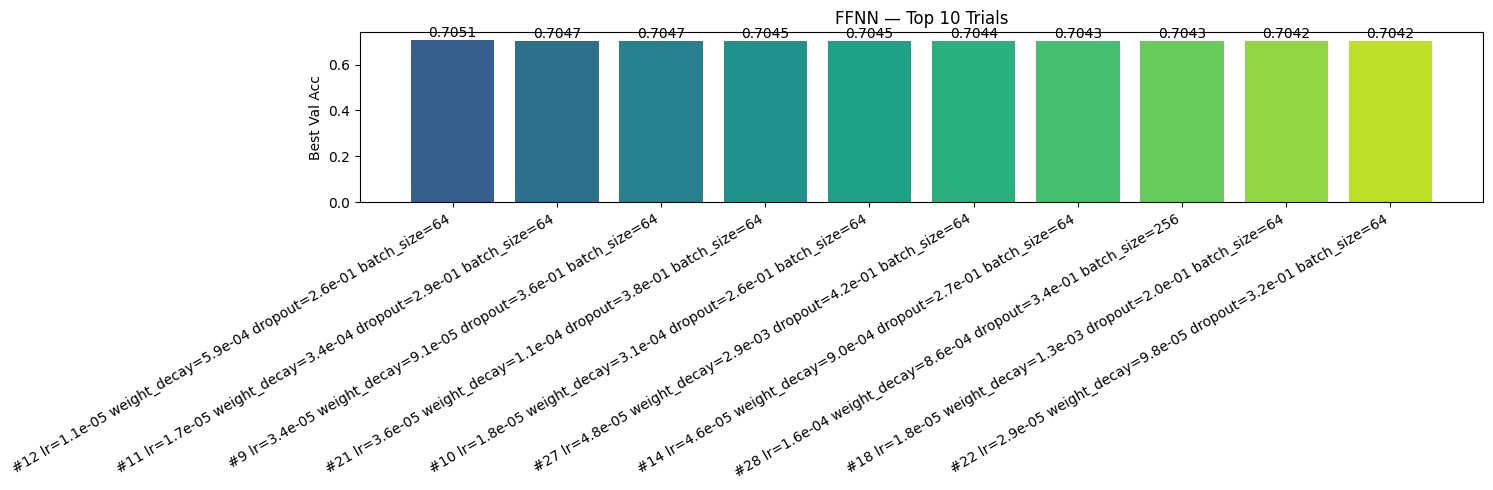

In [10]:
plot_search_results(trial_histories, metric='val_acc', title='FFNN — Top 10 Trials', top_n=10)


## Final Training with Best Parameters

`FFNN_CONFIG` is updated with the best hyperparameters found by Optuna. `train_model` then calls `build_ffnn` internally to construct the model, so it trains from scratch on the full training set with those parameters. The best checkpoint (lowest validation loss) is saved automatically.

In [11]:
FFNN_CONFIG.update(best_params)
model     = FFNN(num_classes=len(classes), dropout=FFNN_CONFIG['dropout'])
optimizer = torch.optim.Adam(model.parameters(),
                              lr=FFNN_CONFIG['lr'],
                              weight_decay=FFNN_CONFIG['weight_decay'])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

In [12]:
history = train_model(build_ffnn, train_loader, val_loader,
                      params=best_params, num_classes=len(classes),
                      epochs=FFNN_CONFIG['epochs'], device=device,
                      patience=FFNN_CONFIG['patience'],
                      save_path='Models/saved_models/ffnn_best.pth')

Epoch 1/150 [train]:   0%|          | 0/1425 [00:00<?, ?it/s]

Epoch 1/150 [val]: 100%|██████████| 179/179 [00:00<00:00, 272.79it/s]

Epoch 1/150 | Train Loss: 0.6271 | Train Acc: 0.6480 | Val Loss: 0.5989 | Val Acc: 0.6873 | LR: 1.58e-04


  -> Saved best model (val_loss=0.5989)


Epoch 2/150 [val]: 100%|██████████| 179/179 [00:00<00:00, 413.18it/s]

...

Epoch 80/150 | Train Loss: 0.5644 | Train Acc: 0.7204 | Val Loss: 0.5755 | Val Acc: 0.7112 | LR: 1.54e-07



Epoch 81/150 [val]: 100%|██████████| 179/179 [00:00<00:00, 345.65it/s]

Epoch 81/150 | Train Loss: 0.5641 | Train Acc: 0.7208 | Val Loss: 0.5755 | Val Acc: 0.7115 | LR: 1.54e-07



Epoch 82/150 [val]: 100%|██████████| 179/179 [00:00<00:00, 360.25it/s]

Epoch 82/150 | Train Loss: 0.5644 | Train Acc: 0.7206 | Val Loss: 0.5754 | Val Acc: 0.7115 | LR: 7.71e-08
Early stopping at epoch 82 (no improvement for 10 epochs)


# Training Curves

Training and validation curves show how loss and accuracy evolved per epoch. The red dashed line marks the epoch where validation loss was lowest — the checkpoint saved at that point is the model we reload for evaluation.

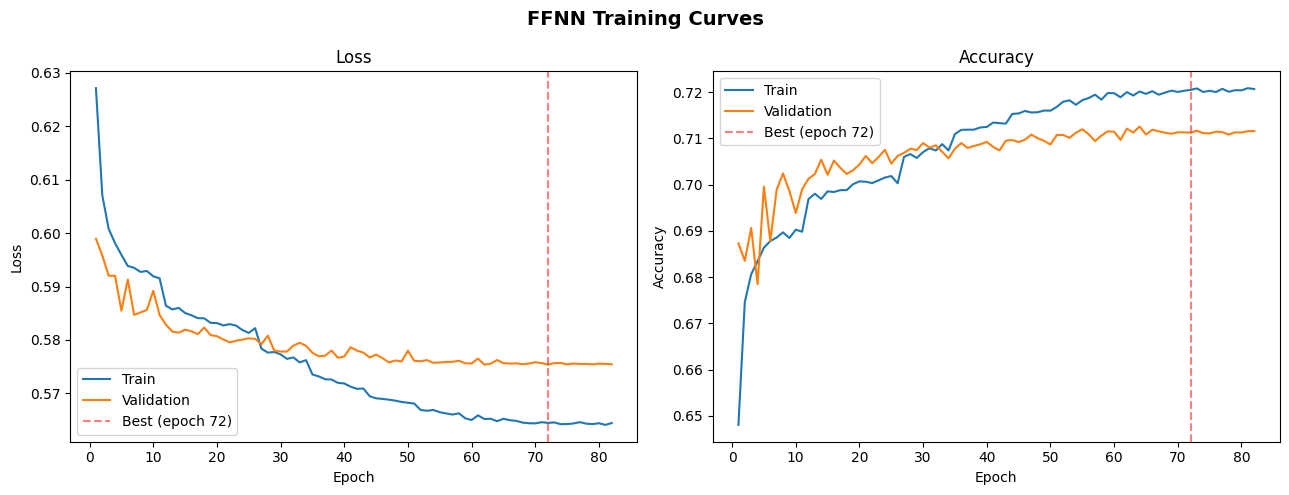

In [13]:
plot_training_curves(history, title='FFNN Training Curves')

# Evaluation

We reload the best checkpoint before running inference — `train_model` saves it during training but the `model` variable in memory holds the last epoch, not the best one.

In [14]:
model = FFNN(num_classes=len(classes), dropout=FFNN_CONFIG['dropout'])
checkpoint = torch.load('Models/saved_models/ffnn_best.pth', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model from epoch {checkpoint['epoch']} "
      f"| val_loss={checkpoint['val_loss']:.4f} | val_acc={checkpoint['val_acc']:.4f}")
model.to(device)

Loaded best model from epoch 72 | val_loss=0.5754 | val_acc=0.7112


FFNN(
  (network): Sequential(
    (0): Linear(in_features=4096, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3374235023366022, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3374235023366022, inplace=False)
    (6): Linear(in_features=256, out_features=128, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.3374235023366022, inplace=False)
    (9): Linear(in_features=128, out_features=2, bias=True)
  )
)

Classification Report:
              precision    recall  f1-score   support

     Cracked       0.87      0.49      0.63     11341
 Non Cracked       0.65      0.92      0.76     11447

    accuracy                           0.71     22788
   macro avg       0.76      0.71      0.70     22788
weighted avg       0.76      0.71      0.70     22788



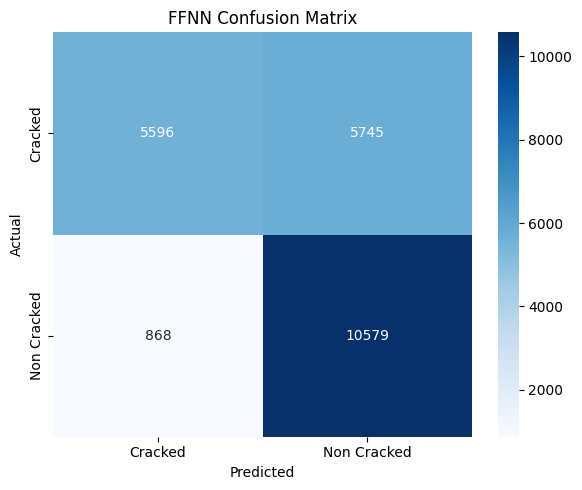

In [15]:
all_preds, all_labels = evaluate_model(model, test_loader, device=device)
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=classes))
plot_confusion_matrix(all_labels, all_preds, class_names=classes, title='FFNN Confusion Matrix')